# ANÁLISE EXPLORATÓRIA DOS DADOS + TREINAMENTO E TESTE DO MODELO DE CLASSIFICAÇÃO (DADOS COLETADOS NO KAGGLE)

---

**Este notebook apresenta uma análise exploratória dos dados ESG SILVER (dados previamente tratados), com o objetivo de compreender o comportamento das variáveis e subsidiar a definição do modelo mais adequado para implementação em produção (deploy).**

---

**DICIONÁRIO BASE SILVER:**

| Coluna              | Descrição                                         | Tipo               | Valores possíveis / Exemplo |
|---------------------|-------------------------------------------------|--------------------|-----------------------------|
| name                | Nome da empresa                                  | String             | Walt Disney Co              |
| exchange            | Bolsa de valores onde a empresa está listada     | String             | NEW YORK STOCK EXCHANGE, INC. |
| environment_level   | Nível de desempenho ambiental                    | Categórico (ordinal) | Low, Medium, High → Ex: High |
| social_level        | Nível de desempenho social                       | Categórico (ordinal) | Low, Medium, High → Ex: Medium |
| governance_level    | Nível de governança corporativa                 | Categórico (ordinal) | Low, Medium, High → Ex: Medium |
| total_level         | Classificação ESG geral da empresa               | Categórico (ordinal) | Low, Medium, High → Ex: High |

- IMPORTS
---

In [173]:
# Manipulação e plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option(
    "display.max_columns", 
    None
)

# Divisão de dados
from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    StratifiedKFold,
    GridSearchCV
)

# Modelos ML
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

- ANÁLISE EXPLORATÓRIA DOS DADOS
---

In [174]:
df = pd.read_csv("../data/silver/esg_reporting_silver.csv")
display(df.head())
df.info()

,name,exchange,environment_score,social_score,governance_score,total_level
0,Walt Disney Co,"NEW YORK STOCK EXCHANGE, INC.",510,316,321,High
1,General Motors Co,"NEW YORK STOCK EXCHANGE, INC.",510,303,255,High
2,WW Grainger Inc,"NEW YORK STOCK EXCHANGE, INC.",255,385,240,Medium
3,Mohawk Industries Inc,"NEW YORK STOCK EXCHANGE, INC.",570,298,303,High
4,Live Nation Entertainment Inc,"NEW YORK STOCK EXCHANGE, INC.",492,310,250,High


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               722 non-null    object
 1   exchange           722 non-null    object
 2   environment_score  722 non-null    int64 
 3   social_score       722 non-null    int64 
 4   governance_score   722 non-null    int64 
 5   total_level        722 non-null    object
dtypes: int64(3), object(3)
memory usage: 34.0+ KB


In [175]:
# Tratamentos iniciais para analise
classes = {
    "Medium": 0,
    "High": 1,
}
df["total_level_encoded"] = df.total_level.map(classes)

df = pd.get_dummies(
    data=df,
    columns=["exchange"],
    dtype=int
)
df.head()

,name,environment_score,social_score,governance_score,total_level,total_level_encoded,exchange_NASDAQ NMS - GLOBAL MARKET,"exchange_NEW YORK STOCK EXCHANGE, INC."
0,Walt Disney Co,510,316,321,High,1,0,1
1,General Motors Co,510,303,255,High,1,0,1
2,WW Grainger Inc,255,385,240,Medium,0,0,1
3,Mohawk Industries Inc,570,298,303,High,1,0,1
4,Live Nation Entertainment Inc,492,310,250,High,1,0,1


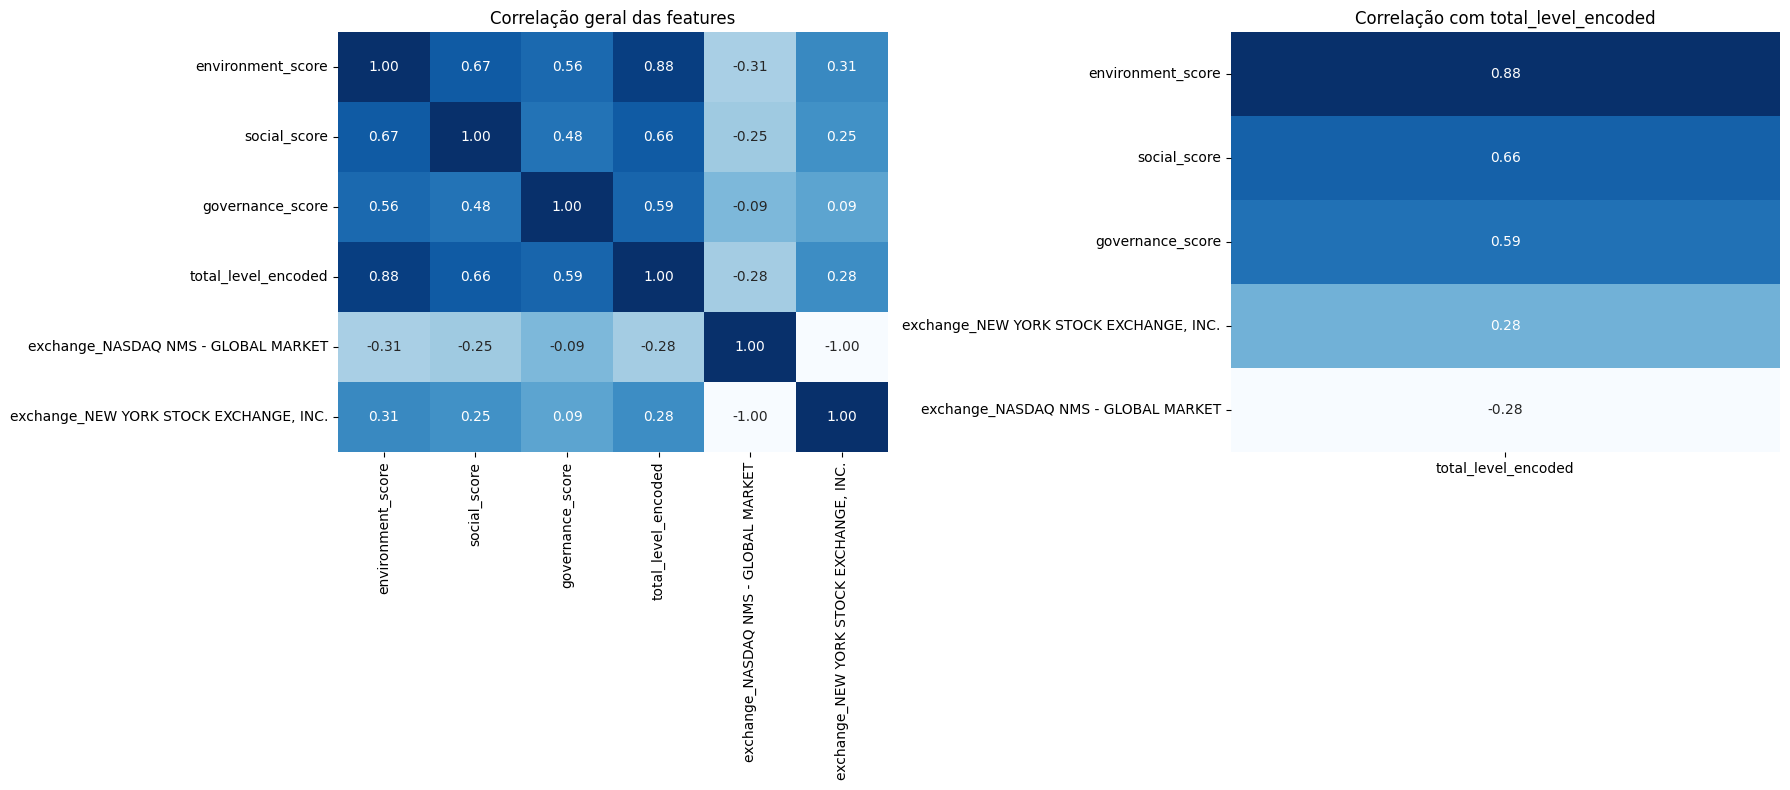

In [176]:
# Análise de correlação
df_corr = df.drop(columns=["name"])

corr_matrix = df_corr.corr(numeric_only=True)

target_corr = corr_matrix["total_level_encoded"].drop("total_level_encoded")
target_corr = target_corr.sort_values(ascending=False)
heatmap_data = target_corr.to_frame()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1) Heatmap 
sns.heatmap(
    corr_matrix,
    annot=True, 
    fmt=".2f",
    cmap="Blues",
        cbar=False,
    ax=axes[0]
)
axes[0].set_title("Correlação geral das features")

# 2) Correlação com target
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("Correlação com total_level_encoded")

plt.tight_layout()
plt.show()

**Análise:** O destaque mais forte é a relação entre **environment_score** e **total_level_encoded**, indicando que o componente ambiental é o principal driver do score ESG total nesse dataset. Porém, os pilares social e governança não ficam pra trás, com uma correlação acima de 59. Isso sugere que as empresas geralmente prezam por fatores ambientais do que social e governamental.

Outro ponto importante é a correlação perfeita negativa entre as dummies das exchanges, o que indica claramente o dummy trap, ou seja, uma coluna é completamente redundante em relação à outra. Com esse detalhe analisando, para o treino do modelo, irei dropar uma das colunas entre esse dummy criado para não causar confusão no modelo.

Em resumo: as features tem ótima correlação com o score total, o que faz sentido, pois, provavelmente é a partir desses scores que conseguimos identificar a maturidade ESG de uma empresa.

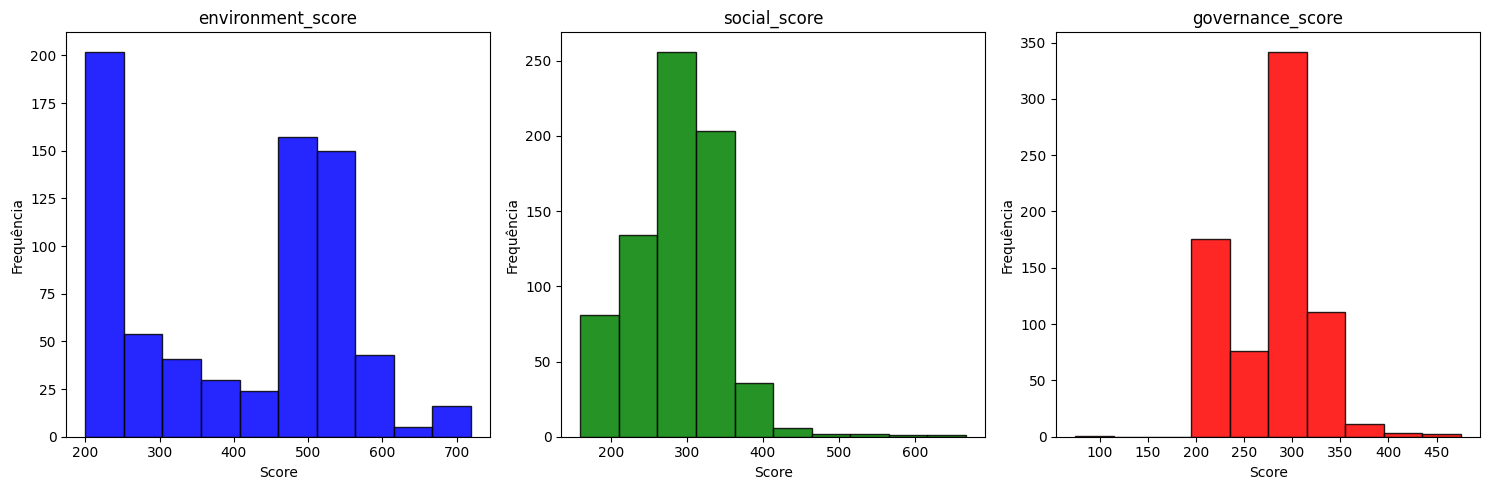

In [177]:
# Análise de destribuição dos pilares esg
cols = [
    "environment_score",
    "social_score",
    "governance_score"
]

colors = ["blue", "green", "red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(
        df[col].dropna(),
        bins=10,
        color=colors[i],
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

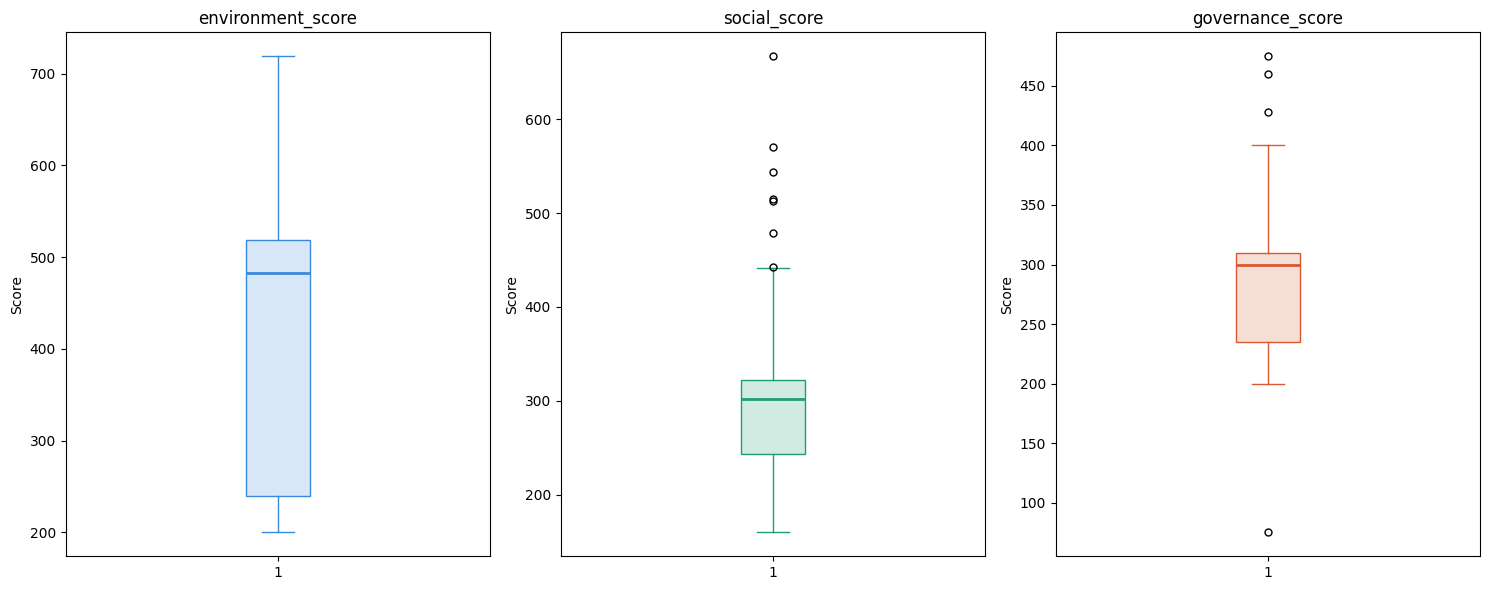

In [178]:
# aNálise de outliers
cols = ["environment_score", "social_score", "governance_score"]
colors = ["#378ADD", "#1D9E75", "#D85A30"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color+"33", color=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color='#E24B4A', markersize=5))
    axes[i].set_title(col)
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [179]:
df[["environment_score",
    "social_score",
    "governance_score"]].describe()

,environment_score,social_score,governance_score
count,722.000000,722.000000,722.000000
mean,404.806094,292.182825,278.761773
std,145.103870,57.017406,47.031536
min,200.000000,160.000000,75.000000
25%,240.000000,243.000000,235.000000
50%,483.000000,302.000000,300.000000
75%,518.750000,322.750000,310.000000
max,719.000000,667.000000,475.000000


**Análise:** Os histogramas e boxplots revelam distribuições distintas entre os três pilares ESG. O `environment_score` apresenta um comportamento bimodal, com uma concentração de empresas na faixa baixa (~200–250) e outro grupo expressivo na faixa média-alta (~500–600). Isso indica que as empresas tendem a se polarizar no desempenho ambiental, com poucas no meio-termo.

O `social_score` tem uma distribuição mais concentrada e aproximadamente normal, com pico em torno de 300–350 e cauda longa à direita. A maioria das empresas apresenta desempenho social similar, com poucos outliers de alta performance.

O `governance_score` é o mais concentrado dos três, com a grande maioria das empresas agrupada entre 250 e 320. Isso indica baixa variabilidade na dimensão de governança. As empresas são mais homogêneas nesse pilar.

Em resumo, o componente ambiental é o que mais diferencia as empresas entre si, enquanto governança apresenta menor poder discriminatório no dataset. Esse padrão é consistente com a análise de correlação anterior, onde environment se destacou como principal driver do score ESG total.

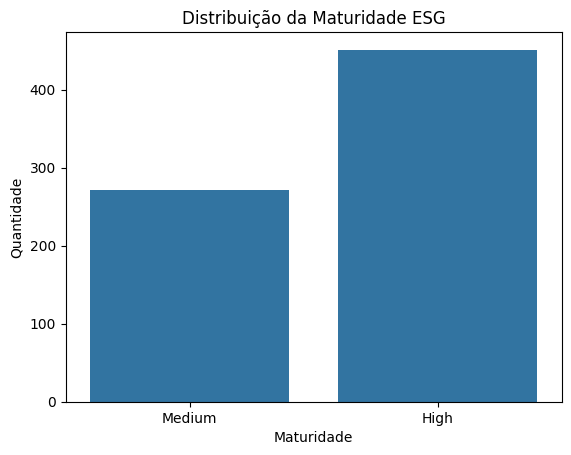

In [180]:
# Análise de desbalanceamento da target (total_level)
target_distribuition = df.total_level.value_counts().sort_values(ascending=True)

sns.barplot(target_distribuition)
plt.title("Distribuição da Maturidade ESG")
plt.xlabel("Maturidade")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

**Análise:** Como visto antes, é possível identificar que na base só existe duas classes registradas: Medium e High. Ou seja, não há nenhuma empresa com maturidade ESG Low ou Excelent. Isso pode ser um problema para previsões futuras, já que o modelo não terá informações para treino sobre as classes baixa ou excelente. 

Após entender melhor sobre meu conjunto de dados, irei partir para a construção do modelo de previsão. Farei todas as etapas e testes necessários para a criação do modelo:
- *Divisão dos dados* 
- *Criação de modelos*
- *Treinos e Testes* 
- *Validando com métricas apropriadas*  

- CRIAÇÃO E VALIDAÇÃO DE MODELO ML (PREVISÃO MATURIDADE ESG)
---

Para iniciar a avaliação do modelo de classificação desenvolvido, a base de dados será dividida em dois subconjuntos: treino e teste. Essa separação é fundamental para que o modelo seja treinado em uma parte dos dados e avaliado em outra ainda não vista, permitindo uma estimativa mais realista de seu desempenho em cenários reais.

Na etapa de divisão dos dados para validação do modelo, será utilizada a técnica de **Validação Cruzada Estratificada** (Stratified K-Fold Cross Validation). As técnicas Holdout e Leave-One-Out não seriam adequadas para esse problema pelos seguintes motivos:

- `HoldOut` -> É mais indicado para bases de dados maiores e balanceadas, onde há dados suficientes para que a divisão aleatória entre treino e teste seja representativa. Como a base em questão é pequena e desbalanceada, uma única divisão poderia gerar subconjuntos com distribuições de classes muito distintas, comprometendo a avaliação do modelo.
- `Leave-One-Out` -> Embora seja recomendado para bases com poucos dados, o custo computacional seria elevado, pois o método treina o modelo *N* vezes, uma para cada amostra da base, utilizando-a individualmente como conjunto de teste. Apesar do tamanho reduzido da base, esse custo ainda seria desnecessariamente alto, sem oferecer ganhos significativos em relação à Validação Cruzada Estratificada.

Para os modelos, serão utilizados 3 algoritmos preditivos de classificação:
- `XGBoost` -> Modelo ensemble baseado em gradient boosting de árvores de decisão
- `K-Nearest Neighbors` -> Modelo baseado em distancia (euclidiana, manhattan...)
- `Decision Tree` -> Modelo baseado em árvore de decisão

O desempenho do modelo será analisado por meio das métricas **Matriz de Confusão**, **Acurácia**, **Precisão** e **Recall**. A matriz de confusão permitirá visualizar os acertos e erros de classificação em cada classe, enquanto as demais métricas fornecerão uma visão quantitativa da capacidade do modelo em realizar previsões corretas e identificar corretamente os exemplos positivos.

*Obs.: o modelo K-Nearest Neighbors provavelmente apresentará melhor desempenho por trabalhar bem com dados numéricos e basear suas previsões na proximidade entre os valores.*

In [181]:
# Utilizando base gold para treinamento de modelo 
df_gold = pd.read_csv("../data/gold/esg_reporting_gold.csv")
df_gold.head()

,environment_score,social_score,governance_score,total_level,exchange_nasdaq nms - global market
0,510,316,321,1,0
1,510,303,255,1,0
2,255,385,240,0,0
3,570,298,303,1,0
4,492,310,250,1,0


In [182]:
# Divisão de dados de treino e teste
df_train, df_test = train_test_split(df_gold, test_size=0.1, random_state=42)
print("df_train: ", df_train.shape)
print("df_test: ", df_test.shape)

df_train:  (649, 5)
df_test:  (73, 5)


In [183]:
# Analisando balanceamento da target nas duas bases
print("Balanceamento da target - df_train\n", df_train.total_level.value_counts(), "\n")
print("Balanceamento da target - df_test\n", df_test.total_level.value_counts())

Balanceamento da target - df_train
 total_level
1    406
0    243
Name: count, dtype: int64 

Balanceamento da target - df_test
 total_level
1    45
0    28
Name: count, dtype: int64


In [184]:
# Divisão x e y 
x = df_train.drop("total_level", axis=1)
y = df_train.total_level

In [185]:
# Criação dos modelos
xgb = XGBClassifier(
    n_estimators=20,
    max_depth=6,
    learning_rate=0.3

)
knn = KNeighborsClassifier(
    n_neighbors=3,
)
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=3
)

**Análise:** O desempenho dos 3 modelos foi exatamente igual em todas as métricas. Geralmente isso não é comum. Isso pode estar acontecendo pelo fato do conjunto de dados ser muito simples. Para ver se os modelos não estão decorando os dados, eles irão prever os dados da base de teste.

*2° Técnica de divisão de dados - K-Fold Cross Validation Stratified*

In [186]:
# Criação dos modelos
xgb_skf = XGBClassifier(
    n_estimators=20,
    max_depth=6,
    learning_rate=0.3

)
knn_skf = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)
tree_skf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=3
)

=========== XGBOOST ===========
Acurácia : 0.9831
Precisão : 0.9823
Recall   : 0.9815

=========== DECISION TREE ===========
Acurácia : 0.9723
Precisão : 0.9704
Recall   : 0.9704

=========== KNN ===========
Acurácia : 0.9861
Precisão : 0.9856
Recall   : 0.9848 



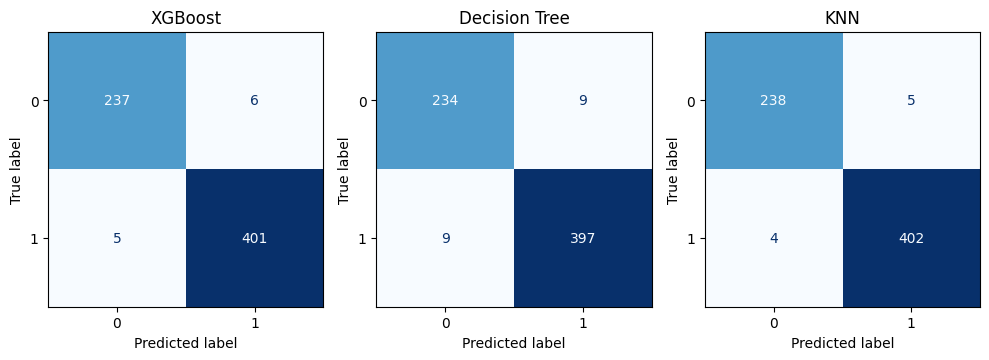

In [187]:
# Analisando desempenho dos modelos (treino e teste com cross_val_predict)
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# XGBoost
xgb_skf_pred = cross_val_predict(xgb_skf, x, y, cv=skf)
tree_skf_pred = cross_val_predict(tree_skf, x, y, cv=skf)
knn_skf_pred = cross_val_predict(knn_skf, x, y, cv=skf)

acc_xgb_skf = accuracy_score(y, xgb_skf_pred)
precision_xgb_skf = precision_score(y, xgb_skf_pred, average="macro")
recall_xgb_skf = recall_score(y, xgb_skf_pred, average="macro")

# Árvore de Decisão
acc_tree_skf = accuracy_score(y, tree_skf_pred)
precision_tree_skf = precision_score(y, tree_skf_pred, average="macro")
recall_tree_skf = recall_score(y, tree_skf_pred, average="macro")

# KNN
acc_knn_skf = accuracy_score(y, knn_skf_pred)
precision_knn_skf = precision_score(y, knn_skf_pred, average="macro")
recall_knn_skf = recall_score(y, knn_skf_pred, average="macro")


print("=========== XGBOOST ===========")
print("Acurácia :", round(acc_xgb_skf, 4))
print("Precisão :", round(precision_xgb_skf, 4))
print("Recall   :", round(recall_xgb_skf, 4))

print("\n=========== DECISION TREE ===========")
print("Acurácia :", round(acc_tree_skf, 4))
print("Precisão :", round(precision_tree_skf, 4))
print("Recall   :", round(recall_tree_skf, 4))

print("\n=========== KNN ===========")
print("Acurácia :", round(acc_knn_skf, 4))
print("Precisão :", round(precision_knn_skf, 4))
print("Recall   :", round(recall_knn_skf, 4), "\n")

# Matrizes de confusão
cm_xgb = confusion_matrix(y, xgb_skf_pred)
cm_tree = confusion_matrix(y, tree_skf_pred)
cm_knn = confusion_matrix(y, knn_skf_pred)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ConfusionMatrixDisplay(cm_xgb).plot(
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay(cm_tree).plot(
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(cm_knn).plot(
    cmap="Blues",
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("KNN")

plt.tight_layout()
plt.show()

**Análise:** Através das métricas e matrizes de confusão, é possível ver que os modelos desempenharam muito bem. Tando na classes 0 como 1. Porém o modelo que teve um maior destaque foi o
`k-Nearest Neighbors` (KNN), com uma acurácia de 98.61%, precisão de 98.56% e recall de 98.48%. Analisando sua matriz de confusão, o modelo só previu 9 dados, em relação a 649 dados, ou seja, ele preveu 640 dados corretamente. Para testar se o modelo realmente está generalizando e não decorando os dados, o modelo KNN será utilizado para prever os dados de teste, que foram isolados do conjunto de treino e validação no início, como tinha dito. Mas antes de testar na base de test, será utilizado a técnica de `GridSearchCV`, onde ele irá buscar os melhores parâmetros para utilizar no modelo.

In [188]:
# Inicalizando otimização de hiperparâmetros
params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

knn_gs = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn_gs,
    param_grid=params,
    scoring="accuracy",
    cv=skf,
    n_jobs=-1
) 

grid.fit(x, y)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


**Análise:** Após a otimização de hiperparâmetros com GridSearchCV, vimos que os valores dos parâmetros já tinham sido colocados anteriormente no Cross Validation. Após isso, seguimos para o teste do desempenho real do modelo em uma base que ainda não foi vista.

In [189]:
# Divisão x de teste 
x_df_test = df_test.drop("total_level", axis=1)
y_df_test = df_test.total_level

In [190]:
# Testando o desempenho do modelo com hiperparâmetros do GridSearch
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="uniform",
    leaf_size=30,
    p=2,
    metric="euclidean"
)
knn.fit(x, y)
y_pred_df_test = knn.predict(x_df_test)


============== MÉTRICAS FINAIS ==============
Acurácia:  0.9726
Precisão:  0.9778
Recall:  0.9778


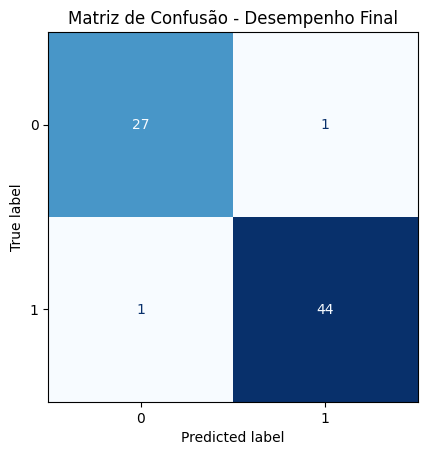

In [194]:
# Métricas finais do desempenho do modelo KNN
acc = accuracy_score(y_df_test, y_pred_df_test)
precision = precision_score(y_df_test, y_pred_df_test)
recall = recall_score(y_df_test, y_pred_df_test)
cm = confusion_matrix(y_df_test, y_pred_df_test)

print("============== MÉTRICAS FINAIS ==============")
print("Acurácia: ", round(acc, 4))
print("Precisão: ", round(precision, 4))
print("Recall: ", round(recall, 4))

ConfusionMatrixDisplay(cm).plot(
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de Confusão - Desempenho Final")
plt.show()